## Imports

In [1]:
import sys
import numpy as np
import pandas as pd
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

In [2]:
%load_ext autoreload
%autoreload 2

## Load dataset

In [3]:
data_path = Path("../exploration/data/coffee_sales_prepared.parquet")

df = pd.read_parquet(data_path)
df.head()

,date,datetime,cash_type,card,money,coffee_name,hour,day_of_week,day_of_week_num,month,year,is_weekend,season
0,2024-03-01,2024-03-01 10:15:50.520,card,anon-0000-0000-0001,38.7,latte,10,Friday,4,3,2024,False,spring
1,2024-03-01,2024-03-01 12:19:22.539,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
2,2024-03-01,2024-03-01 12:20:18.089,card,anon-0000-0000-0002,38.7,hot chocolate,12,Friday,4,3,2024,False,spring
3,2024-03-01,2024-03-01 13:46:33.006,card,anon-0000-0000-0003,28.9,americano,13,Friday,4,3,2024,False,spring
4,2024-03-01,2024-03-01 13:48:14.626,card,anon-0000-0000-0004,38.7,latte,13,Friday,4,3,2024,False,spring


## Daily series

In [4]:
daily_sales = (
    df.groupby("date")
    .size()
    .rename("sales_quantity")
    .to_frame()
    .sort_index()
)

daily_sales.index = pd.to_datetime(daily_sales.index)

daily_sales.head()

,sales_quantity
date,
2024-03-01,11
2024-03-02,7
2024-03-03,10
2024-03-04,4
2024-03-05,9


In [5]:
# confirmando se existe uma linha para cada dia
complete_dates = pd.date_range(
    start=daily_sales.index.min(),
    end=daily_sales.index.max(),
    freq="D"
)

missing_dates = complete_dates.difference(daily_sales.index)

print(f"Período: {daily_sales.index.min().date()} a "
      f"{daily_sales.index.max().date()}")

print(f"Quantidade de dias observados: {len(daily_sales)}")
print(f"Quantidade de dias ausentes: {len(missing_dates)}")

display(missing_dates)

Período: 2024-03-01 a 2025-03-23
Quantidade de dias observados: 381
Quantidade de dias ausentes: 7


DatetimeIndex(['2024-05-01', '2024-05-04', '2024-05-05', '2024-11-27',
               '2025-01-01', '2025-01-19', '2025-01-23'],
              dtype='datetime64[ns]', freq=None)

In [6]:
daily_sales = daily_sales.asfreq("D")

daily_sales["was_missing"] = (
    daily_sales["sales_quantity"].isna()
)

daily_sales["sales_quantity"] = (
    daily_sales["sales_quantity"]
    .fillna(0)
    .astype(int)
)

In [7]:
daily_sales[daily_sales["was_missing"]]
# não entrará no modelo, apenas pra auditoria. pode indicar possível problema na máquina de vendas, por exemplo.

,sales_quantity,was_missing
date,,
2024-05-01,0,True
2024-05-04,0,True
2024-05-05,0,True
2024-11-27,0,True
2025-01-01,0,True
2025-01-19,0,True
2025-01-23,0,True


## Check incomplete registries

In [8]:
display(daily_sales.tail(10))

,sales_quantity,was_missing
date,,
2025-03-14,23,False
2025-03-15,7,False
2025-03-16,5,False
2025-03-17,13,False
2025-03-18,17,False
2025-03-19,21,False
2025-03-20,20,False
2025-03-21,20,False
2025-03-22,12,False


In [9]:
last_datetime = df["datetime"].max()

print(f"Última transação: {last_datetime}")
print(f"Última data: {last_datetime.date()}")
print(f"Horário da última transação: {last_datetime.time()}")

Última transação: 2025-03-23 18:11:38.635000
Última data: 2025-03-23
Horário da última transação: 18:11:38.635000


In [10]:
daily_summary = (
    df.groupby("date")
    .agg(
        sales_quantity=("coffee_name", "size"),
        first_transaction=("datetime", "min"),
        last_transaction=("datetime", "max")
    )
    .sort_index()
)

display(daily_summary.tail(10))

,sales_quantity,first_transaction,last_transaction
date,,,
2025-03-14,23,2025-03-14 07:55:05.952,2025-03-14 21:40:43.586
2025-03-15,7,2025-03-15 09:53:22.276,2025-03-15 19:51:27.089
2025-03-16,5,2025-03-16 09:32:17.307,2025-03-16 14:22:42.633
2025-03-17,13,2025-03-17 06:54:40.633,2025-03-17 16:46:44.575
2025-03-18,17,2025-03-18 08:23:10.985,2025-03-18 21:20:40.031
2025-03-19,21,2025-03-19 07:03:07.073,2025-03-19 18:31:25.990
2025-03-20,20,2025-03-20 08:13:16.283,2025-03-20 21:50:15.613
2025-03-21,20,2025-03-21 07:06:11.979,2025-03-21 18:59:24.271
2025-03-22,12,2025-03-22 09:05:13.059,2025-03-22 19:16:52.727


In [11]:
display(daily_summary.tail(10))

,sales_quantity,first_transaction,last_transaction
date,,,
2025-03-14,23,2025-03-14 07:55:05.952,2025-03-14 21:40:43.586
2025-03-15,7,2025-03-15 09:53:22.276,2025-03-15 19:51:27.089
2025-03-16,5,2025-03-16 09:32:17.307,2025-03-16 14:22:42.633
2025-03-17,13,2025-03-17 06:54:40.633,2025-03-17 16:46:44.575
2025-03-18,17,2025-03-18 08:23:10.985,2025-03-18 21:20:40.031
2025-03-19,21,2025-03-19 07:03:07.073,2025-03-19 18:31:25.990
2025-03-20,20,2025-03-20 08:13:16.283,2025-03-20 21:50:15.613
2025-03-21,20,2025-03-21 07:06:11.979,2025-03-21 18:59:24.271
2025-03-22,12,2025-03-22 09:05:13.059,2025-03-22 19:16:52.727


## Train-test split

In [12]:
forecast_horizon = 30

train = daily_sales.iloc[:-forecast_horizon].copy()
test = daily_sales.iloc[-forecast_horizon:].copy()

print(f"Treino: {train.index.min().date()} a "
      f"{train.index.max().date()}")

print(f"Teste: {test.index.min().date()} a "
      f"{test.index.max().date()}")

print(f"Observações de treino: {len(train)}")
print(f"Observações de teste: {len(test)}")

Treino: 2024-03-01 a 2025-02-21
Teste: 2025-02-22 a 2025-03-23
Observações de treino: 358
Observações de teste: 30


## Baseline seazoning

hipótese considerada: as vendas dos próximos dias serão semelhantes às vendas dos mesmos dias da última semana observada.

In [13]:
last_week = train["sales_quantity"].tail(7).to_numpy()

baseline_predictions = np.resize( # cria uma cópia do array last_week para o tomanho do forecast_horizon
    last_week,
    forecast_horizon
)

baseline_forecast = pd.Series(
    baseline_predictions,
    index=test.index,
    name="baseline_forecast"
)

## Metrics

In [17]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

def calculate_forecast_metrics(y_true, y_pred):
    mae = round(mean_absolute_error(y_true, y_pred), 2)

    rmse = round(
        np.sqrt(mean_squared_error(y_true, y_pred)),
        2
    )

    wape = round(
        np.mean(np.abs((y_true - y_pred) / y_true)) * 100,
        2
    )

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE (%)": wape
    }

In [18]:
baseline_metrics = calculate_forecast_metrics(
    y_true=test["sales_quantity"],
    y_pred=baseline_forecast
)

baseline_metrics

{'MAE': 3.17, 'RMSE': np.float64(3.81), 'WAPE (%)': np.float64(30.87)}

In [19]:
def calculate_horizon_results(y_true, y_pred):
    results = []

    for horizon in [1, 7, 30]:
        actual_total = y_true.iloc[:horizon].sum()
        predicted_total = y_pred.iloc[:horizon].sum()

        absolute_error = abs(actual_total - predicted_total)

        percentage_error = (
            absolute_error / actual_total * 100
            if actual_total != 0
            else np.nan
        )

        results.append({
            "horizon": f"{horizon} day(s)",
            "actual_sales": actual_total,
            "predicted_sales": predicted_total,
            "absolute_error": absolute_error,
            "percentage_error": percentage_error
        })

    return pd.DataFrame(results)

In [20]:
baseline_horizon_results = calculate_horizon_results(
    y_true=test["sales_quantity"],
    y_pred=baseline_forecast
)

baseline_horizon_results

,horizon,actual_sales,predicted_sales,absolute_error,percentage_error
0,1 day(s),5,9,4,80.000000
1,7 day(s),99,119,20,20.202020
2,30 day(s),418,495,77,18.421053


## Models

## Holt-winters

In [32]:
from statsmodels.tsa.holtwinters import ExponentialSmoothing

y_train = train["sales_quantity"]
y_test = test["sales_quantity"]


In [ ]:

hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)

hw_forecast = hw_model.forecast(len(test))
hw_forecast.name = "exponential_smoothing_forecast"

## SARIMAX

In [18]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(test))
sarima_forecast.name = "sarima_forecast"

## pre processing for tree based model

In [33]:
df.columns

Index(['date', 'datetime', 'cash_type', 'card', 'money', 'coffee_name', 'hour',
       'day_of_week', 'day_of_week_num', 'month', 'year', 'is_weekend',
       'season'],
      dtype='object')

In [32]:
daily_sales.columns

Index(['sales_quantity', 'was_missing'], dtype='object')

In [19]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   date             3636 non-null   datetime64[ns]
 1   datetime         3636 non-null   datetime64[ns]
 2   cash_type        3636 non-null   string        
 3   card             3547 non-null   string        
 4   money            3636 non-null   float64       
 5   coffee_name      3636 non-null   string        
 6   hour             3636 non-null   int32         
 7   day_of_week      3636 non-null   object        
 8   day_of_week_num  3636 non-null   int32         
 9   month            3636 non-null   int32         
 10  year             3636 non-null   int32         
 11  is_weekend       3636 non-null   bool          
 12  season           3636 non-null   object        
dtypes: bool(1), datetime64[ns](2), float64(1), int32(4), object(2), string(3)
memory usage: 287.7

In [ ]:
# df["date"] = pd.to_datetime(df["date"])
# df["datetime"] = pd.to_datetime(df["datetime"])

daily_sales = (
    df.groupby("date")
    .size()
    .rename("sales_quantity")
    .to_frame()
    .sort_index()
)

daily_sales = daily_sales.asfreq("D")
daily_sales["was_missing"] = daily_sales["sales_quantity"].isna()
daily_sales["sales_quantity"] = daily_sales["sales_quantity"].fillna(0).astype(int)
daily_sales["day_of_week_num"] = daily_sales.index.dayofweek
daily_sales["month"] = daily_sales.index.month
daily_sales["year"] = daily_sales.index.year
daily_sales["is_weekend"] = daily_sales["day_of_week_num"].isin([5, 6]).astype(int)

In [23]:
def get_season(month):
    if month in [12, 1, 2]:
        return "winter"
    elif month in [3, 4, 5]:
        return "spring"
    elif month in [6, 7, 8]:
        return "summer"
    else:
        return "autumn"

daily_sales["season"] = daily_sales["month"].apply(get_season)

In [24]:
daily_sales["lag_1"] = daily_sales["sales_quantity"].shift(1)
daily_sales["lag_7"] = daily_sales["sales_quantity"].shift(7)
daily_sales["lag_14"] = daily_sales["sales_quantity"].shift(14)
daily_sales["lag_28"] = daily_sales["sales_quantity"].shift(28)

daily_sales["rolling_mean_7"] = (
    daily_sales["sales_quantity"].shift(1).rolling(7).mean()
)

daily_sales["rolling_mean_14"] = (
    daily_sales["sales_quantity"].shift(1).rolling(14).mean()
)

In [24]:
daily_sales

,sales_quantity,was_missing,day_of_week_num,month,year,is_weekend,season,lag_1,lag_7,lag_14,lag_28,rolling_mean_7,rolling_mean_14
date,,,,,,,,,,,,,
2024-03-01,11,False,4,3,2024,0,spring,NaN,NaN,NaN,NaN,NaN,NaN
2024-03-02,7,False,5,3,2024,1,spring,11.0,NaN,NaN,NaN,NaN,NaN
2024-03-03,10,False,6,3,2024,1,spring,7.0,NaN,NaN,NaN,NaN,NaN
2024-03-04,4,False,0,3,2024,0,spring,10.0,NaN,NaN,NaN,NaN,NaN
2024-03-05,9,False,1,3,2024,0,spring,4.0,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2025-03-19,21,False,2,3,2025,0,spring,17.0,17.0,19.0,20.0,13.428571,13.428571
2025-03-20,20,False,3,3,2025,0,spring,21.0,12.0,12.0,19.0,14.000000,13.571429
2025-03-21,20,False,4,3,2025,0,spring,20.0,23.0,17.0,23.0,15.142857,14.142857


In [27]:
daily_sales['season'].unique()

array(['spring', 'summer', 'autumn', 'winter'], dtype=object)

In [25]:
modeling_df = pd.get_dummies(
    daily_sales,
    columns=["season"],
    drop_first=False
)

In [30]:
modeling_df.columns

Index(['sales_quantity', 'was_missing', 'day_of_week_num', 'month', 'year',
       'is_weekend', 'lag_1', 'lag_7', 'lag_14', 'lag_28', 'rolling_mean_7',
       'rolling_mean_14', 'season_autumn', 'season_spring', 'season_summer',
       'season_winter'],
      dtype='object')

In [52]:
correlation_features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",
    "day_of_week_num",
    "month",
    "is_weekend",
    "season_spring",
    "season_summer",
    "season_winter",
    "season_autumn",
    "sales_quantity"
]

corr_matrix = modeling_df[correlation_features].corr(method="spearman")

corr_matrix["sales_quantity"].sort_values(ascending=False)

sales_quantity     1.000000
rolling_mean_7     0.486991
rolling_mean_14    0.446171
lag_1              0.341594
lag_7              0.303860
lag_14             0.229173
season_autumn      0.214340
lag_28             0.110279
month              0.063874
season_winter      0.038788
season_spring     -0.100130
is_weekend        -0.138286
season_summer     -0.144514
day_of_week_num   -0.147611
Name: sales_quantity, dtype: float64

<Figure size 1000x400 with 0 Axes>

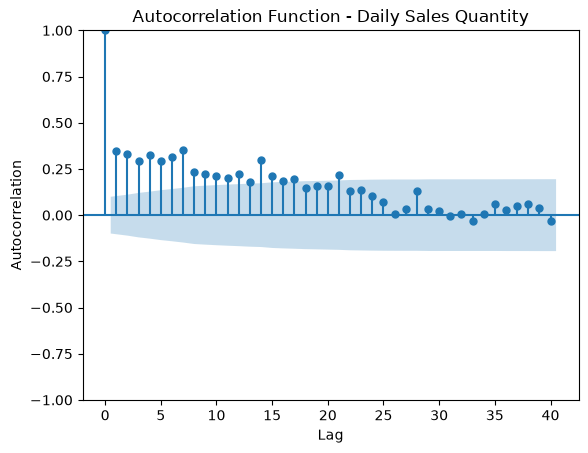

In [50]:
from statsmodels.graphics.tsaplots import plot_acf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plot_acf(
    daily_sales["sales_quantity"],
    lags=40
)
plt.title("Autocorrelation Function - Daily Sales Quantity")
plt.xlabel("Lag")
plt.ylabel("Autocorrelation")
plt.show()

<Figure size 1000x400 with 0 Axes>

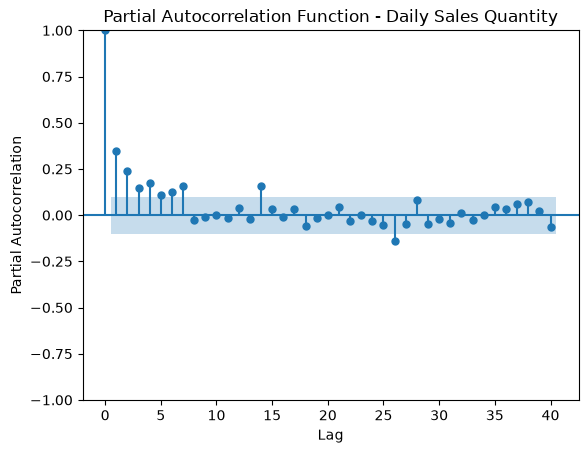

In [51]:
from statsmodels.graphics.tsaplots import plot_pacf
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plot_pacf(
    daily_sales["sales_quantity"],
    lags=40,
    method="ywm"
)
plt.title("Partial Autocorrelation Function - Daily Sales Quantity")
plt.xlabel("Lag")
plt.ylabel("Partial Autocorrelation")
plt.show()

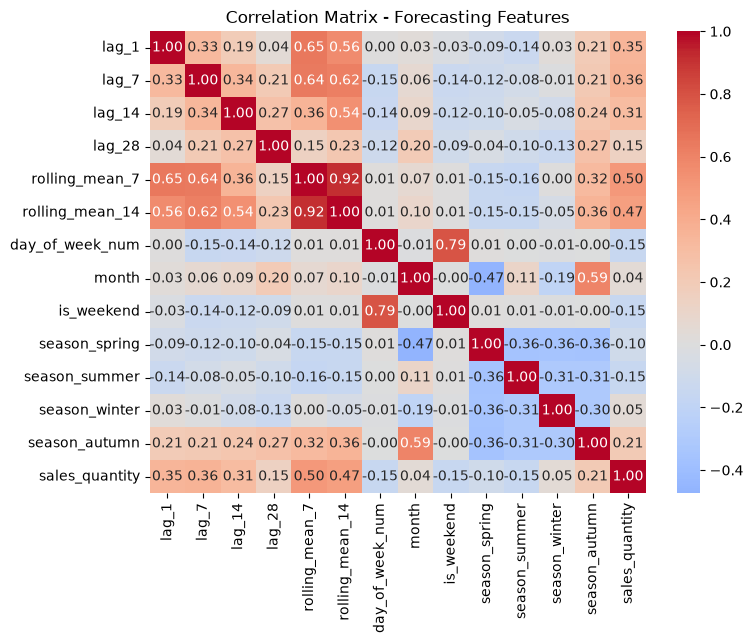

In [27]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix - Forecasting Features")
plt.show()

## RF

In [42]:
ml_train = modeling_df.iloc[:-30].copy()
ml_test = modeling_df.iloc[-30:].copy()

features = [
    "lag_1",
    "lag_7",
    "lag_14",
    "lag_28",
    "rolling_mean_7",
    "rolling_mean_14",   
]

X_train = ml_train[features]
y_train_ml = ml_train["sales_quantity"]

X_test = ml_test[features]
y_test_ml = ml_test["sales_quantity"]

## Prediction and evalutation models

In [29]:
import pandas as pd
import numpy as np

from statsmodels.tsa.holtwinters import ExponentialSmoothing
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

In [43]:
def calculate_forecast_metrics(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100

    return {
        "MAE": mae,
        "RMSE": rmse,
        "WAPE (%)": wape
    }

Baseline Seasonal Naive: considera a sazonalidade semanal, ou seja, o valor previsto para um dia é o valor observado 7 dias antes.

In [44]:
seasonal_period = 7

baseline_forecast = y_test.copy()

for i, date in enumerate(y_test.index):
    lag_date = date - pd.Timedelta(days=seasonal_period)

    if lag_date in train.index:
        baseline_forecast.loc[date] = train.loc[lag_date, "sales_quantity"]
    elif lag_date in test.index:
        baseline_forecast.loc[date] = test.loc[lag_date, "sales_quantity"]
    else:
        baseline_forecast.loc[date] = y_train.iloc[-seasonal_period]

baseline_forecast.name = "baseline_seasonal_naive_forecast"

Exponential Smoothing

In [45]:
hw_model = ExponentialSmoothing(
    y_train,
    trend="add",
    seasonal="add",
    seasonal_periods=7
).fit(optimized=True)

hw_forecast = hw_model.forecast(len(test))
hw_forecast.name = "exponential_smoothing_forecast"

SARIMA

In [46]:
sarima_model = SARIMAX(
    y_train,
    order=(1, 1, 1),
    seasonal_order=(1, 1, 1, 7),
    enforce_stationarity=False,
    enforce_invertibility=False
).fit(disp=False)

sarima_forecast = sarima_model.forecast(steps=len(test))
sarima_forecast.name = "sarima_forecast"

Random Forest

In [47]:
rf_model = RandomForestRegressor(
    n_estimators=300,
    max_depth=5,
    random_state=42
)

rf_model.fit(X_train, y_train_ml)

rf_forecast = pd.Series(
    rf_model.predict(X_test),
    index=ml_test.index,
    name="random_forest_lags_forecast"
)

In [48]:
forecasts = {
    "Baseline Seasonal Naive": baseline_forecast,
    "Exponential Smoothing": hw_forecast,
    "SARIMA": sarima_forecast,
    "RF with Lags": rf_forecast
}

results = []

for model_name, forecast in forecasts.items():
    common_index = y_test.index.intersection(forecast.index)

    metrics = calculate_forecast_metrics(
        y_test.loc[common_index],
        forecast.loc[common_index]
    )

    metrics["model"] = model_name
    metrics["horizon"] = "full_test"
    results.append(metrics)

results_full_test = pd.DataFrame(results).set_index("model")
results_full_test.sort_values("WAPE (%)")

,MAE,RMSE,WAPE (%),horizon
model,,,,
Baseline Seasonal Naive,3.000000,3.750556,21.531100,full_test
RF with Lags,4.307726,4.967578,30.916691,full_test
Exponential Smoothing,5.559630,6.798316,39.901651,full_test
SARIMA,5.708178,7.025001,40.967786,full_test


In [49]:
horizons = {
    "next_day": 1,
    "next_week": 7,
    "next_month": 30
}

results = []

for horizon_name, horizon_steps in horizons.items():
    for model_name, forecast in forecasts.items():
        common_index = y_test.index.intersection(forecast.index)
        horizon_index = common_index[:horizon_steps]

        metrics = calculate_forecast_metrics(
            y_test.loc[horizon_index],
            forecast.loc[horizon_index]
        )

        metrics["model"] = model_name
        metrics["horizon"] = horizon_name
        metrics["n_days"] = len(horizon_index)

        results.append(metrics)

results_by_horizon = pd.DataFrame(results)

results_by_horizon = results_by_horizon[
    ["horizon", "n_days", "model", "MAE", "RMSE", "WAPE (%)"]
]

results_by_horizon.sort_values(["horizon", "WAPE (%)"])

,horizon,n_days,model,MAE,RMSE,WAPE (%)
0,next_day,1,Baseline Seasonal Naive,4.000000,4.000000,80.000000
3,next_day,1,RF with Lags,8.766405,8.766405,175.328110
1,next_day,1,Exponential Smoothing,12.427517,12.427517,248.550343
2,next_day,1,SARIMA,12.505576,12.505576,250.111517
8,next_month,30,Baseline Seasonal Naive,3.000000,3.750556,21.531100
11,next_month,30,RF with Lags,4.307726,4.967578,30.916691
9,next_month,30,Exponential Smoothing,5.559630,6.798316,39.901651
10,next_month,30,SARIMA,5.708178,7.025001,40.967786
4,next_week,7,Baseline Seasonal Naive,3.428571,4.000000,24.242424
7,next_week,7,RF with Lags,4.642484,5.461891,32.825643


## Results view

In [39]:
len(y_test)

30

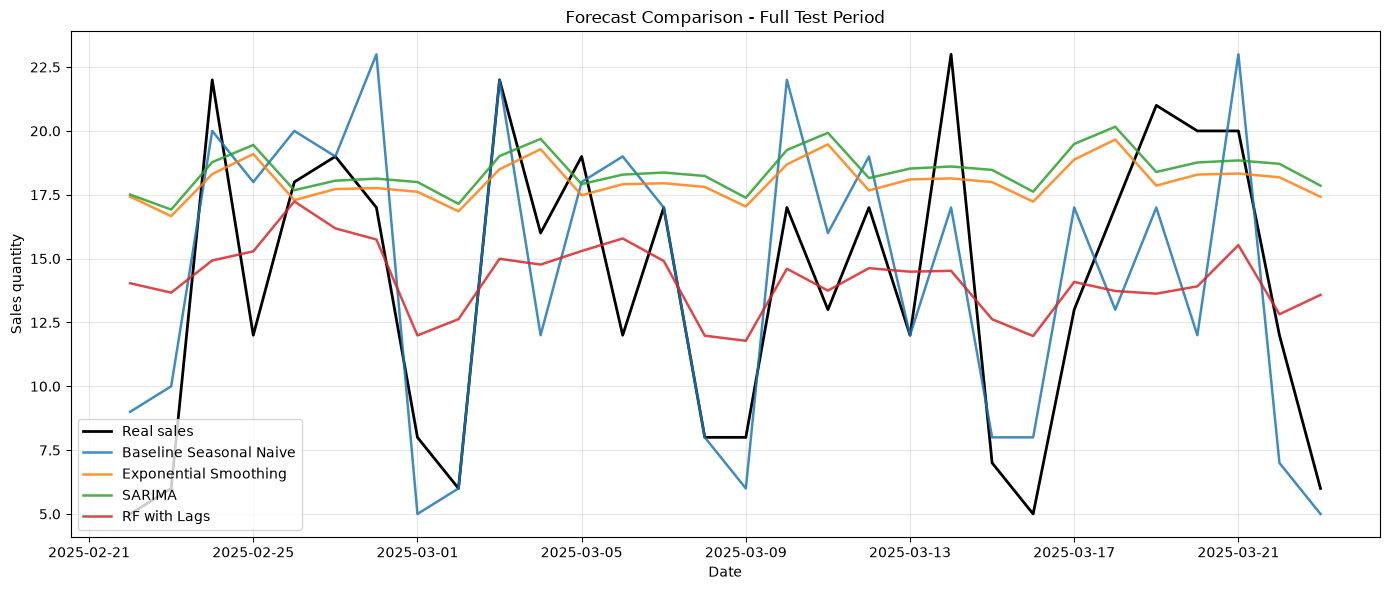

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 6))

plt.plot(
    y_test.index,
    y_test,
    label="Real sales",
    color="black",
    linewidth=2
)

for model_name, forecast in forecasts.items():
    common_index = y_test.index.intersection(forecast.index)

    plt.plot(
        common_index,
        forecast.loc[common_index],
        label=model_name,
        linewidth=1.8,
        alpha=0.85
    )

plt.title("Forecast Comparison - Full Test Period")
plt.xlabel("Date")
plt.ylabel("Sales quantity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()